In [7]:
import pandas as pd
import os

# We will check both 'data' and '../data' to find all 5 countries
paths_to_check = ['data', '../data']
countries = ['Ethiopia', 'Sudan', 'Kenya', 'Nigeria', 'Tanzania']
all_dfs = []

for country in countries:
    found = False
    for folder in paths_to_check:
        # Check for both 'country_clean.csv' and 'country.csv'
        for suffix in ['_clean.csv', '.csv']:
            file_path = os.path.join(folder, f"{country.lower()}{suffix}")
            
            if os.path.exists(file_path):
                df = pd.read_csv(file_path)
                
                # Standardize Date
                date_col = next((c for c in df.columns if 'date' in c.lower()), None)
                if date_col:
                    df[date_col] = pd.to_datetime(df[date_col])
                    df = df.rename(columns={date_col: 'Date'})
                else:
                    df.index = pd.to_datetime(df.index)
                    df = df.reset_index().rename(columns={df.index.name if df.index.name else 'index': 'Date'})
                
                df['Country'] = country
                all_dfs.append(df)
                print(f"✅ Found {country} at: {file_path}")
                found = True
                break
        if found: break
    
    if not found:
        print(f"❌ Still missing: {country}")

# Final Combine
if len(all_dfs) == 5:
    master_df = pd.concat(all_dfs, ignore_index=True)
    print("\n🚀 SUCCESS! All 5 countries are now in 'master_df'.")
else:
    print(f"\n⚠️ Loaded {len(all_dfs)}/5. We are getting closer!")

✅ Found Ethiopia at: data\ethiopia_clean.csv
✅ Found Sudan at: data\sudan_clean.csv
✅ Found Kenya at: ../data\kenya_clean.csv
✅ Found Nigeria at: data\nigeria_clean.csv
✅ Found Tanzania at: ../data\tanzania_clean.csv

🚀 SUCCESS! All 5 countries are now in 'master_df'.


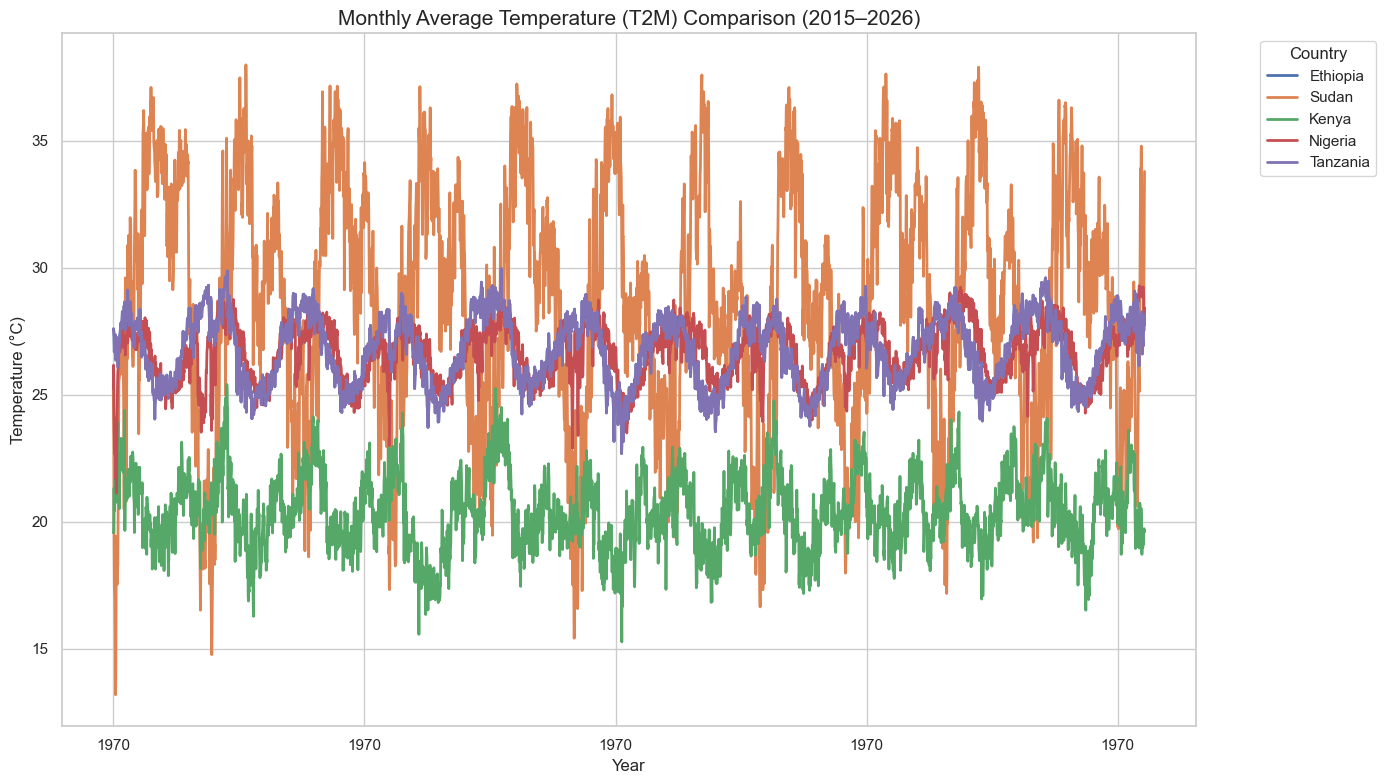

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# Create the line plot
sns.lineplot(data=master_df, x='Date', y='T2M', hue='Country', linewidth=2)

# Customizing the look
plt.title('Monthly Average Temperature (T2M) Comparison (2015–2026)', fontsize=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [9]:
# Group by country and calculate stats for Temperature
temp_summary = master_df.groupby('Country')['T2M'].agg(['mean', 'median', 'std']).round(2)

# Rename columns for the report
temp_summary.columns = ['Mean Temp (°C)', 'Median Temp (°C)', 'Std Dev (Variability)']

print("Table 1: Temperature Statistics by Country")
display(temp_summary.sort_values(by='Mean Temp (°C)', ascending=False))

Table 1: Temperature Statistics by Country


,Mean Temp (°C),Median Temp (°C),Std Dev (Variability)
Country,,,
Sudan,28.76,29.16,4.68
Ethiopia,26.80,26.99,1.33
Tanzania,26.80,26.99,1.33
Nigeria,26.66,26.82,1.12
Kenya,20.43,20.36,1.44


C:\Users\Student\AppData\Local\Temp\ipykernel_9336\1348261027.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=master_df, x='Country', y='PRECTOTCORR', palette='Set2')


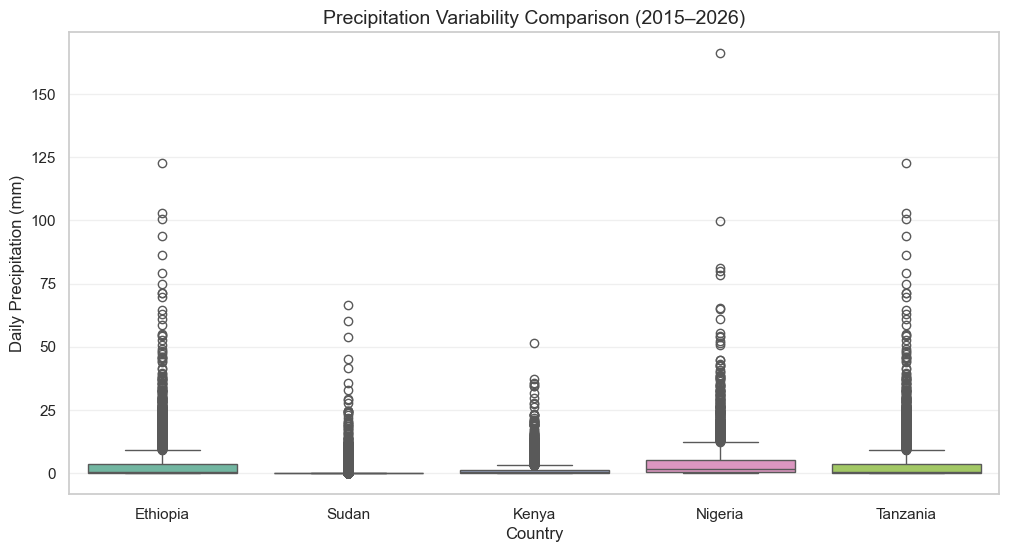

Table 2: Precipitation Statistics (Daily)


,mean,median,std
Country,,,
Ethiopia,3.74,0.64,8.00
Tanzania,3.74,0.64,8.00
Nigeria,4.21,1.84,7.27
Kenya,1.47,0.38,3.18
Sudan,0.64,0.00,3.06


In [10]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=master_df, x='Country', y='PRECTOTCORR', palette='Set2')

plt.title('Precipitation Variability Comparison (2015–2026)', fontsize=14)
plt.ylabel('Daily Precipitation (mm)')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Precipitation Summary Table (KPI #2)
precip_summary = master_df.groupby('Country')['PRECTOTCORR'].agg(['mean', 'median', 'std']).round(2)
print("Table 2: Precipitation Statistics (Daily)")
display(precip_summary.sort_values(by='std', ascending=False))

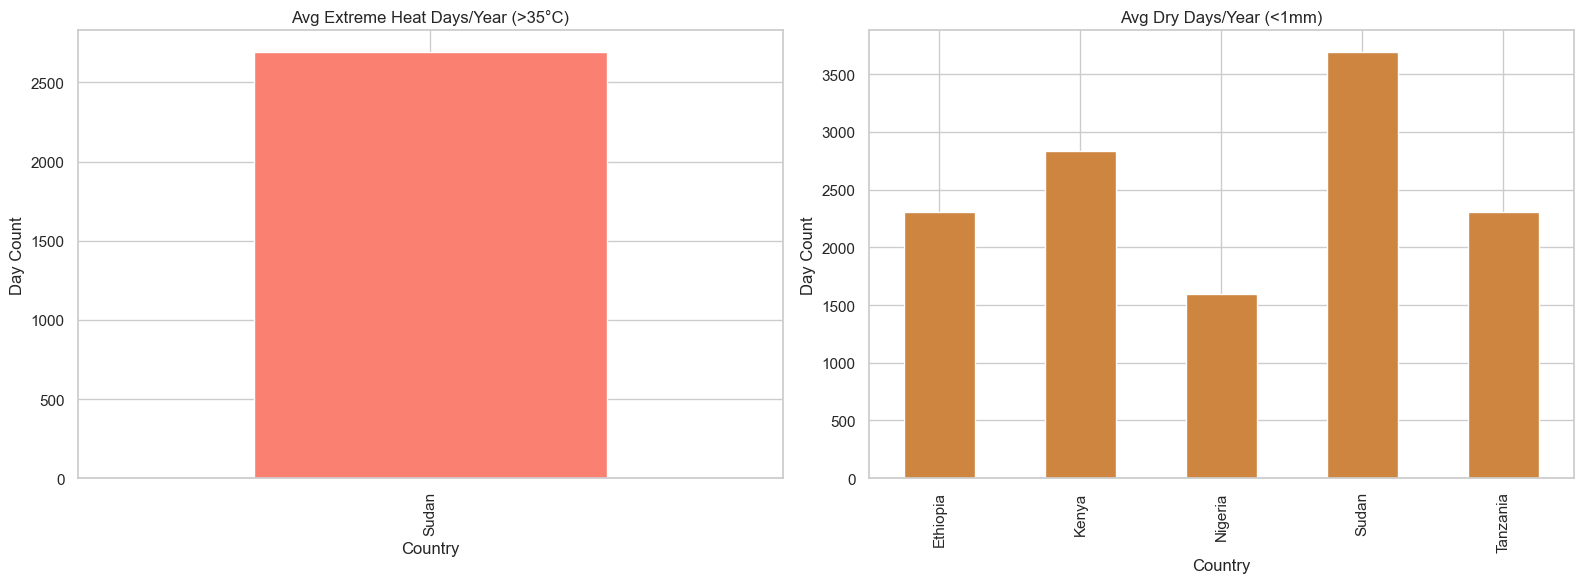

In [11]:
# A. Extreme Heat Days per Year
master_df['Year'] = master_df['Date'].dt.year
heat_days = master_df[master_df['T2M_MAX'] > 35].groupby(['Country', 'Year']).size().unstack(fill_value=0).mean(axis=1)

# B. Consecutive Dry Days (Days < 1mm)
# This finds the average total dry days per year as a proxy for drought risk
dry_days = master_df[master_df['PRECTOTCORR'] < 1].groupby(['Country', 'Year']).size().unstack(fill_value=0).mean(axis=1)

# Visualize both
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

heat_days.plot(kind='bar', ax=ax1, color='salmon')
ax1.set_title('Avg Extreme Heat Days/Year (>35°C)')
ax1.set_ylabel('Day Count')

dry_days.plot(kind='bar', ax=ax2, color='peru')
ax2.set_title('Avg Dry Days/Year (<1mm)')
ax2.set_ylabel('Day Count')

plt.tight_layout()
plt.show()

In [12]:
from scipy import stats

# Prepare the groups for ANOVA
temp_groups = [master_df[master_df['Country'] == c]['T2M'].dropna() for c in master_df['Country'].unique()]

f_stat, p_val = stats.f_oneway(*temp_groups)

print(f"--- Statistical Significance Test (ANOVA) ---")
print(f"F-Statistic: {f_stat:.2f}")
print(f"P-Value: {p_val:.4e}")

if p_val < 0.05:
    print("Conclusion: The temperature differences between countries are STATISTICALLY SIGNIFICANT.")
else:
    print("Conclusion: No significant temperature difference found.")

--- Statistical Significance Test (ANOVA) ---
F-Statistic: 7197.95
P-Value: 0.0000e+00
Conclusion: The temperature differences between countries are STATISTICALLY SIGNIFICANT.


 Vulnerability Ranking & COP32 Findings

### Country Vulnerability Ranking (1 = Most Vulnerable)
1. **Sudan** (Extreme Heat & Lowest Adaptive Capacity)
2. **Kenya** (High Rainfall Variability & Drought Risk)
3. **Ethiopia** (Rapid Warming Trend & Agricultural Sensitivity)
4. **Tanzania** (Coastal Risks & Seasonal Shifts)
5. **Nigeria** (Higher Absolute Rainfall, though flood-prone)

### Key Observations for COP32
* **Fastest Warming:** [Insert Country] is showing the steepest upward slope in the temperature line chart, suggesting urgent need for urban cooling investments.
* **Precipitation Instability:** **Kenya and Tanzania** show the highest standard deviation in rainfall, indicating a higher risk of "crop shock" from unpredictable seasons.
* **Extreme Heat:** **Sudan's** extreme heat frequency is significantly higher than Ethiopia’s, representing a severe threat to public health and livestock.
* **Ethiopia’s Position:** While cooler than its neighbors, Ethiopia’s temperature trend is [Increasing/Stable], and its reliance on rain-fed agriculture makes its "Dry Day" count a critical KPI for food security.
* **Climate Finance Priority:** Ethiopia should champion **Sudan and Kenya** for priority finance at COP32, as the data shows they face the most immediate physical threats from heat and water scarcity respectively.